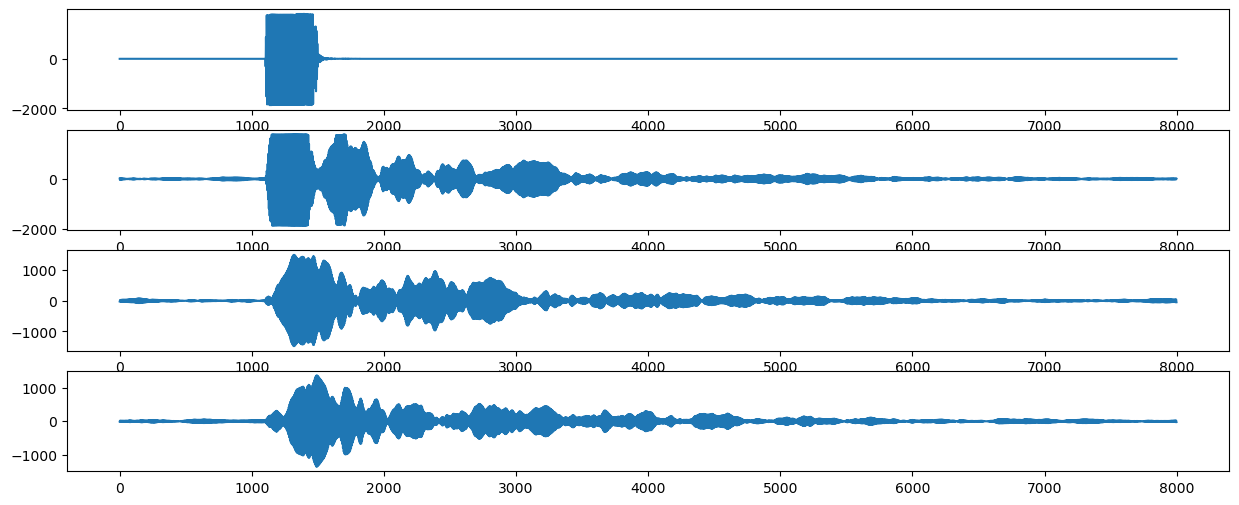

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

filename = "air_ISI.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
plt.subplot(4,1,1)
plt.plot(rx_signal)

filename = "tank_close_ISI.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
plt.subplot(4,1,2)
plt.plot(rx_signal)

filename = "tank_ISI.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
plt.subplot(4,1,3)
plt.plot(rx_signal)

filename = "tank_far_ISI.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
plt.subplot(4,1,4)
plt.plot(rx_signal)

In [3]:
def apply_hilbert(span):
    taps = [-0.09, 0.0, -0.58, 0.0, 0.58, 0.0, 0.09]
    sum = 0
    for i in range(7):
        sum += span[i] * taps[i];
    return sum

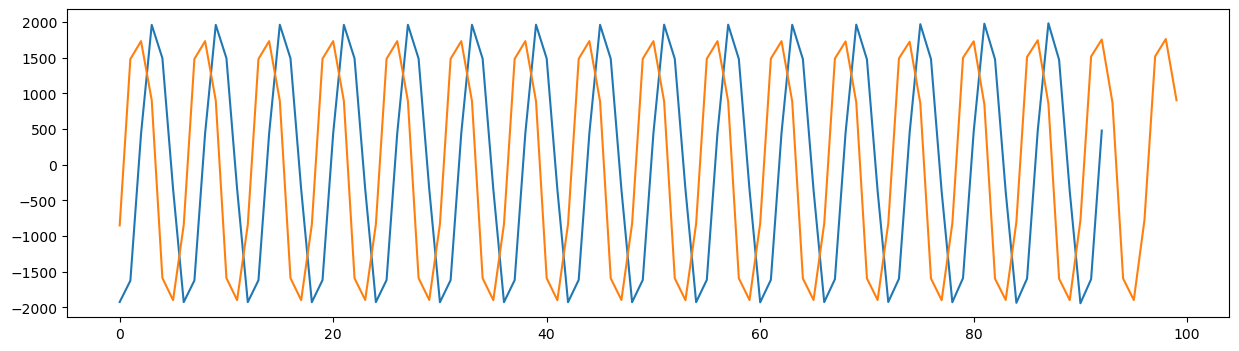

In [4]:
from scipy.signal import hilbert
from collections import deque

filename = "air_ISI.npy"
rx_signal = np.load(filename).astype(float)[1250:1350]
rx_signal-=np.mean(rx_signal)
buffer=deque(rx_signal[:7])
rx_complex=np.zeros(len(rx_signal)-7)
for i in range(len(rx_signal)-7):
    rx_complex[i]=apply_hilbert(buffer)
    buffer.popleft()
    buffer.append(rx_signal[i+7])
plt.figure(figsize=(15,4))
plt.plot(rx_complex)
plt.plot(rx_signal)